In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import pandas as pd

data = pd.read_csv("Housing.csv")

print(data.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [3]:
print("Shape:", data.shape)

print("\nColumn Names:")
print(data.columns)

print("\nMissing Values:")
print(data.isnull().sum())

Shape: (545, 13)

Column Names:
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

Missing Values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in data.select_dtypes(include='object'):
    data[col] = encoder.fit_transform(data[col])

print(data.head())

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus  
0                 0  
1                 0  
2                 1  
3                 0  
4                 0  


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    int64
 6   guestroom         545 non-null    int64
 7   basement          545 non-null    int64
 8   hotwaterheating   545 non-null    int64
 9   airconditioning   545 non-null    int64
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    int64
 12  furnishingstatus  545 non-null    int64
dtypes: int64(13)
memory usage: 55.5 KB


In [7]:
X = data.drop("price", axis=1)

y = data["price"]

print(X.head())
print(y.head())

   area  bedrooms  bathrooms  stories  mainroad  guestroom  basement  \
0  7420         4          2        3         1          0         0   
1  8960         4          4        4         1          0         0   
2  9960         3          2        2         1          0         1   
3  7500         4          2        2         1          0         1   
4  7420         4          1        2         1          1         1   

   hotwaterheating  airconditioning  parking  prefarea  furnishingstatus  
0                0                1        2         1                 0  
1                0                1        3         0                 0  
2                0                0        2         1                 1  
3                0                1        3         1                 0  
4                0                1        2         0                 0  
0    13300000
1    12250000
2    12250000
3    12215000
4    11410000
Name: price, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(436, 12)
(109, 12)


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [11]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[5203691.70963177 7257004.02115475 3062828.59668172 4559591.65374424
 3332932.30559783 3563080.67918996 5645466.3121997  6413979.66873635
 2755831.54819001 2668938.6607523 ]


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE =", mae)
print("MSE =", mse)
print("R2 Score =", r2)

MAE = 979679.6912959907
MSE = 1771751116594.0408
R2 Score = 0.6494754192267793


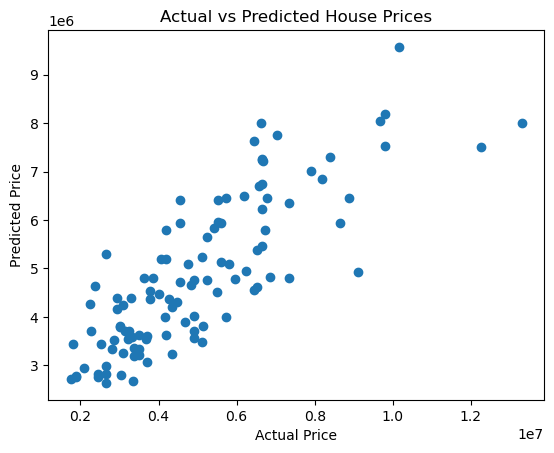

In [13]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest R2 Score =", rf_r2)

Random Forest R2 Score = 0.6118077610803518


In [15]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression R2 Score =", ridge_r2)

Ridge Regression R2 Score = 0.6493602620702652


In [16]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

lasso = Lasso(alpha=1.0)

lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso Regression R2 Score =", lasso_r2)

Lasso Regression R2 Score = 0.6494750689899618


In [17]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gbr.fit(X_train, y_train)

gbr_pred = gbr.predict(X_test)

gbr_r2 = r2_score(y_test, gbr_pred)

print("Gradient Boosting R2 Score =", gbr_r2)

Gradient Boosting R2 Score = 0.6646855642239725


In [21]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

gbr_tuned = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr_tuned.fit(X_train, y_train)

gbr_tuned_pred = gbr_tuned.predict(X_test)

gbr_tuned_r2 = r2_score(y_test, gbr_tuned_pred)

print("Tuned Gradient Boosting R2 Score =", gbr_tuned_r2)

Tuned Gradient Boosting R2 Score = 0.6749030445981601


In [22]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Random Forest",
        "Gradient Boosting",
        "Tuned Gradient Boosting"
    ],
    "R2 Score": [
        r2,
        ridge_r2,
        lasso_r2,
        rf_r2,
        gbr_r2,
        gbr_tuned_r2
    ]
})

print(results)

                     Model  R2 Score
0        Linear Regression  0.649475
1         Ridge Regression  0.649360
2         Lasso Regression  0.649475
3            Random Forest  0.611808
4        Gradient Boosting  0.664686
5  Tuned Gradient Boosting  0.674903


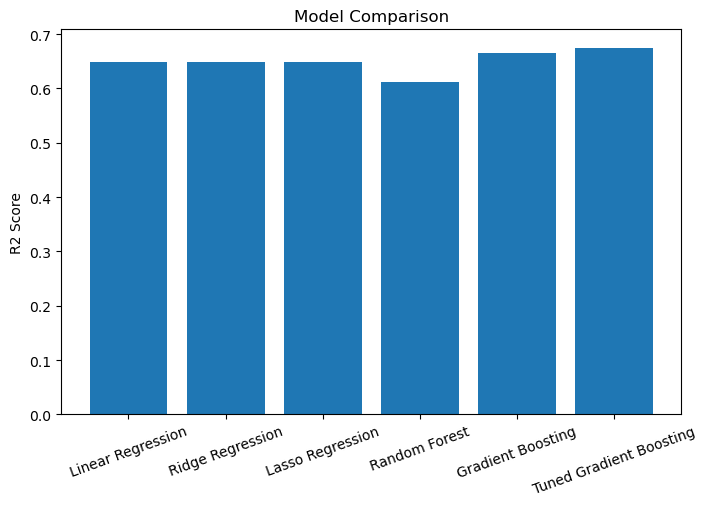

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["R2 Score"])

plt.title("Model Comparison")
plt.ylabel("R2 Score")
plt.xticks(rotation=20)

plt.show()

In [24]:
best_model = results.loc[results["R2 Score"].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Model       Tuned Gradient Boosting
R2 Score                   0.674903
Name: 5, dtype: object


In [25]:
print("Project Completed Successfully!")
print("Best Model: Tuned Gradient Boosting Regressor")
print("Best R2 Score:", gbr_tuned_r2)

Project Completed Successfully!
Best Model: Tuned Gradient Boosting Regressor
Best R2 Score: 0.6749030445981601
